# PCL Detection — Exploratory Data Analysis

Two EDA techniques:
1. Class Balance (train vs dev)
2. Keyword/Topic Skew (PCL rate by keyword)

## 1. Data Loading

In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

df_pcl = pd.read_csv(
    "Data/dontpatronizeme_pcl.tsv",
    sep="\t",
    header=None,
    skiprows=4,
    names=["par_id", "art_id", "keyword", "country", "text", "label"],
)
train_lbl = pd.read_csv("Data/train_semeval_parids-labels.csv")
dev_lbl   = pd.read_csv("Data/dev_semeval_parids-labels.csv")

train_lbl["label_vec"] = train_lbl["label"].apply(ast.literal_eval)
dev_lbl["label_vec"]   = dev_lbl["label"].apply(ast.literal_eval)

train_lbl["y"] = train_lbl["label_vec"].apply(lambda v: int(sum(v) > 0))
dev_lbl["y"]   = dev_lbl["label_vec"].apply(lambda v: int(sum(v) > 0))

train = df_pcl.merge(train_lbl[["par_id","y"]], on="par_id", how="inner")
dev   = df_pcl.merge(dev_lbl[["par_id","y"]],   on="par_id", how="inner")

print("Train size:", len(train), "| Dev size:", len(dev)) 

Train size: 8375 | Dev size: 2094


## 2. EDA Technique 1: Class Balance

,split,n_total,n_no_pcl,n_pcl,pcl_rate
0,train,8375,7581,794,0.094806
1,dev,2094,1895,199,0.095033


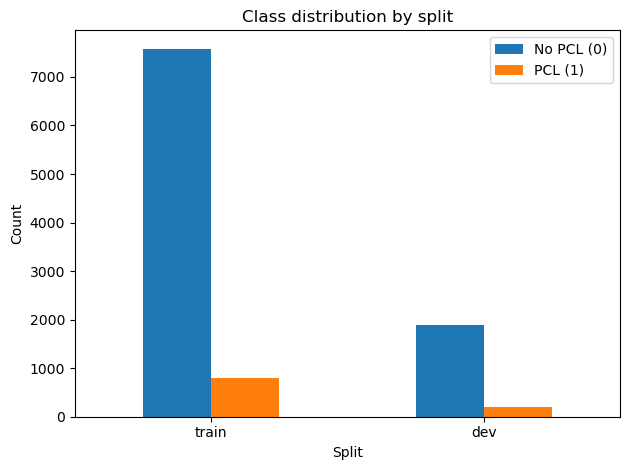

In [3]:
def split_summary(df, name):
    vc = df["y"].value_counts().reindex([0,1]).fillna(0).astype(int)
    total = vc.sum()
    return pd.DataFrame({
        "split": [name],
        "n_total": [total],
        "n_no_pcl": [vc.loc[0]],
        "n_pcl": [vc.loc[1]],
        "pcl_rate": [vc.loc[1] / total],
    })

summary = pd.concat([split_summary(train, "train"),
                     split_summary(dev, "dev")], ignore_index=True)
display(summary)

counts = pd.DataFrame({
    "train": train["y"].value_counts().reindex([0,1]).fillna(0),
    "dev":   dev["y"].value_counts().reindex([0,1]).fillna(0),
}).T
counts.columns = ["No PCL (0)", "PCL (1)"]

counts.plot(kind="bar")
plt.title("Class distribution by split")
plt.xlabel("Split")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("images/class_dist_by_split.png", dpi=150, bbox_inches="tight")
plt.show() 

## 3. EDA Technique 2: Keyword/Topic Skew

,keyword,n,pcl_rate
1,homeless,865,0.172254
4,in-need,856,0.167056
6,poor-families,719,0.155772
2,hopeless,788,0.124365
7,refugee,880,0.082955
0,disabled,834,0.080336
8,vulnerable,871,0.068886
9,women,837,0.045400
5,migrant,882,0.035147
3,immigrant,843,0.027284


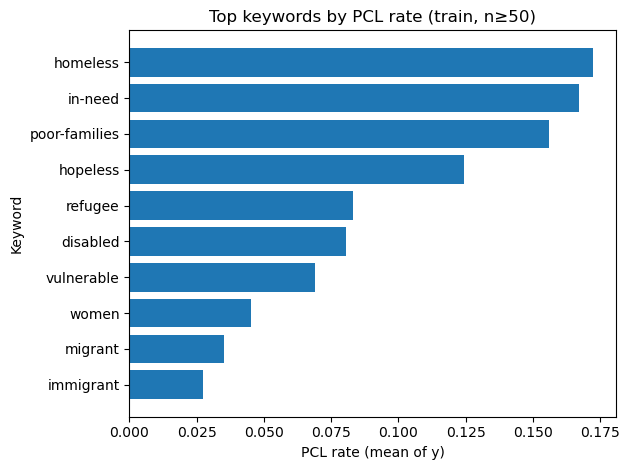

In [4]:
kw_stats = (
    train.groupby("keyword")["y"]
    .agg(n="count", pcl_rate="mean")
    .reset_index()
)

kw_stats_f = kw_stats[kw_stats["n"] >= 50].sort_values("pcl_rate", ascending=False)
display(kw_stats_f)

plot_df = kw_stats_f.sort_values("pcl_rate", ascending=True)
plt.barh(plot_df["keyword"], plot_df["pcl_rate"])
plt.title("Top keywords by PCL rate (train, n≥50)")
plt.xlabel("PCL rate (mean of y)")
plt.ylabel("Keyword")
plt.tight_layout()
plt.savefig("images/keyword_pcl_rate_train.png", dpi=150, bbox_inches="tight")
plt.show() 

### Train vs dev keyword PCL rate comparison

In [5]:
kw_train = train.groupby("keyword")["y"].agg(n_train="count", pcl_train="mean").reset_index()
kw_dev   = dev.groupby("keyword")["y"].agg(n_dev="count", pcl_dev="mean").reset_index()

kw_compare = kw_train.merge(kw_dev, on="keyword")
kw_compare["abs_delta"] = (kw_compare["pcl_train"] - kw_compare["pcl_dev"]).abs()
kw_compare = kw_compare.sort_values("abs_delta", ascending=False)

corr = kw_compare["pcl_train"].corr(kw_compare["pcl_dev"])
print(f"Train/dev keyword PCL rate correlation: {corr:.3f}")
display(kw_compare) 

Train/dev keyword PCL rate correlation: 0.908


,keyword,n_train,pcl_train,n_dev,pcl_dev,abs_delta
6,poor-families,719,0.155772,190,0.200000,0.044228
1,homeless,865,0.172254,212,0.136792,0.035462
8,vulnerable,871,0.068886,209,0.095694,0.026807
4,in-need,856,0.167056,226,0.146018,0.021038
9,women,837,0.045400,233,0.060086,0.014686
7,refugee,880,0.082955,188,0.069149,0.013806
5,migrant,882,0.035147,207,0.024155,0.010993
0,disabled,834,0.080336,194,0.072165,0.008171
3,immigrant,843,0.027284,218,0.032110,0.004827
2,hopeless,788,0.124365,217,0.119816,0.004550
